Primer Parcial

Estudiante: Chelsea Melany Espinoza Cava

Carrera: Ing. de Sistemas

El conjunto de datos de viviendas de Ames contiene 82 variables explicativas que describen (casi) todos los aspectos de las viviendas residenciales en Ames, Iowa, con el objetivo de predecir el precio de venta.

In [48]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

In [49]:
# Carga (usando todas las columnas disponibles)
df = pd.read_csv('AmesHousing.csv')
print(df.head())
df.shape

   Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0      1  526301100           20        RL         141.0     31770   Pave   
1      2  526350040           20        RH          80.0     11622   Pave   
2      3  526351010           20        RL          81.0     14267   Pave   
3      4  526353030           20        RL          93.0     11160   Pave   
4      5  527105010           60        RL          74.0     13830   Pave   

  Alley Lot Shape Land Contour  ... Pool Area Pool QC  Fence Misc Feature  \
0   NaN       IR1          Lvl  ...         0     NaN    NaN          NaN   
1   NaN       Reg          Lvl  ...         0     NaN  MnPrv          NaN   
2   NaN       IR1          Lvl  ...         0     NaN    NaN         Gar2   
3   NaN       Reg          Lvl  ...         0     NaN    NaN          NaN   
4   NaN       IR1          Lvl  ...         0     NaN  MnPrv          NaN   

  Misc Val Mo Sold Yr Sold Sale Type  Sale Condition  SalePrice  
0       

(2930, 82)

In [50]:
# Verificar nulos
print("\n--- Conteo de Nulos por Columna ---")
nulos = df.isnull().sum()
print(nulos[nulos > 0])

print(f"\nTotal general de nulos: {df.isnull().sum().sum()}")


--- Conteo de Nulos por Columna ---
Lot Frontage       490
Alley             2732
Mas Vnr Type      1775
Mas Vnr Area        23
Bsmt Qual           80
Bsmt Cond           80
Bsmt Exposure       83
BsmtFin Type 1      80
BsmtFin SF 1         1
BsmtFin Type 2      81
BsmtFin SF 2         1
Bsmt Unf SF          1
Total Bsmt SF        1
Electrical           1
Bsmt Full Bath       2
Bsmt Half Bath       2
Fireplace Qu      1422
Garage Type        157
Garage Yr Blt      159
Garage Finish      159
Garage Cars          1
Garage Area          1
Garage Qual        159
Garage Cond        159
Pool QC           2917
Fence             2358
Misc Feature      2824
dtype: int64

Total general de nulos: 15749


In [51]:
# El KNN no puede procesar palabras, así que convertimos todo a números primero.
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col].astype(str))

print("\n¡Letras convertidas a números con éxito!")


¡Letras convertidas a números con éxito!


In [52]:
# Aplicamos la fórmula: z = (x - media) / desviación_estándar
# Esto es obligatorio para que el KNN calcule bien las distancias.
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

In [53]:
# Aquí llenamos TODOS los nulos (los 15,749) usando los 5 vecinos más cercanos.
knn = KNNImputer(n_neighbors=5)
df_final = pd.DataFrame(knn.fit_transform(df_scaled), columns=df.columns)

# Verificación final de nulos
print(f"\nNulos después de KNN: {df_final.isnull().sum().sum()}")


Nulos después de KNN: 0


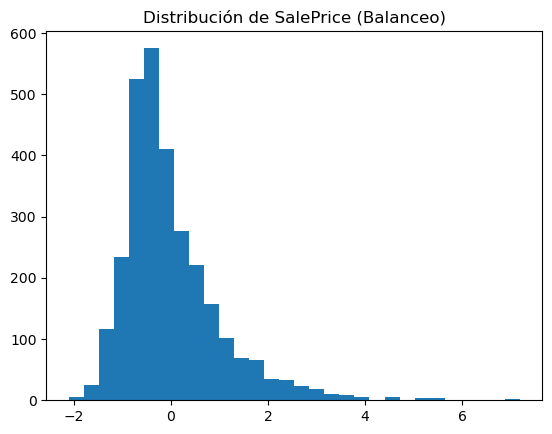

In [54]:
# Ver balanceo/distribución de la variable objetivo (SalePrice)
plt.hist(df_final['SalePrice'], bins=30)
plt.title('Distribución de SalePrice (Balanceo)')
plt.show()

In [ ]:
# Preparamos los insumos para el entrenamiento
# Definir X (todas menos SalePrice) y y (SalePrice)
X = df_final.drop('SalePrice', axis=1).values
y = df_final['SalePrice'].values

# División 80% entrenamiento, 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Entrenamiento (X_train): {X_train.shape}")
print(f"Prueba (X_test): {X_test.shape}")


Entrenamiento (X_train): (2344, 81)
Prueba (X_test): (586, 81)


In [ ]:
print(f"¿Quedan nulos en el dataset?: {df_final.isnull().sum().sum()}")
print(f"Registros totales procesados: {df_final.shape[0]}")

¿Quedan nulos en el dataset?: 0
Registros totales procesados: 2930
¡Dataset 1 preparado con KNN y Z-score!
